In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict

from sandbox.jordan8 import *

import json
import os

In [2]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.double()

C:\Users\micha\AppData\Local\Temp\ipykernel_8340\4232358046.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [3]:
def per_power_features(X):
    d = X.shape[0]

    feat_per_k = []
    N_k = X.clone()

    for k in range(1, d):
        feat_per_k.append(N_k.flatten())
        N_k = N_k @ X  # Next power
    
    return torch.stack(feat_per_k)   # (d-1, d*d), (d-1,)

In [4]:
def run_model(A):
    d = A.shape[0]
    feat = torch.stack([per_power_features(A)])
    logits = model(d, feat)
    probs = torch.softmax(logits, dim=-1)
    return probs[0]

In [5]:
torch.manual_seed(123)
np.random.seed(123)
random.seed(123)

d=15
superdiag = torch.tensor(get_superdiagonal(7, 15))
J = torch.diag(superdiag, diagonal=1)
S = torch.randn(d,d).double()
E = torch.randn(d,d).double()
A_0 = torch.linalg.inv(S) @ J @ S

eps = 1e-5

A = torch.tensor(A_0 + eps * E)
init_probs = run_model(A)

C:\Users\micha\AppData\Local\Temp\ipykernel_8340\452543619.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  A = torch.tensor(A_0 + eps * E)


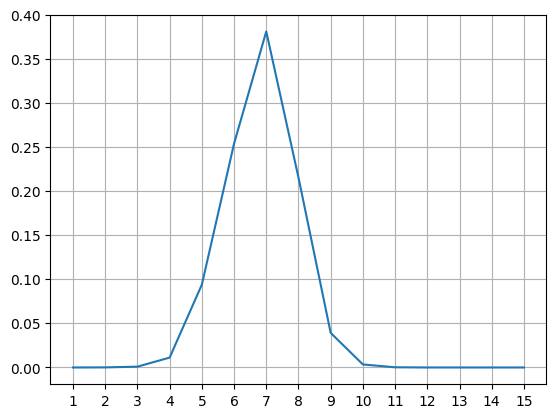

In [6]:
plt.plot(init_probs)
plt.grid()
plt.xticks(ticks=range(d), labels=range(1, d+1))
plt.show()

In [7]:
target_distr = soft_target(7, eps=0, d=d)

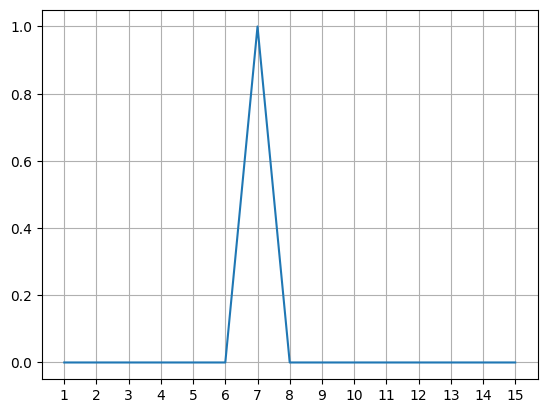

In [8]:
plt.plot(target_distr)
plt.grid()
plt.xticks(ticks=range(d), labels=range(1, d+1))
plt.show()

In [9]:
def cost(A):
    probs = run_model(A)
    return torch.norm(target_distr-probs)

In [10]:
A_param = torch.nn.Parameter(A.clone())
optimizer = torch.optim.Adam([A_param], lr=1e-4)

best = A_param.clone()
best_loss = float('inf')

for i in range(10_000):
    optimizer.zero_grad()
    loss = cost(A_param)
    if loss < best_loss:
        best = A_param.clone()
        best_loss = loss
    loss.backward()
    optimizer.step()
    print(f"{i}: {loss}")

0: 0.7021837112111177
1: 0.7692967002319496
2: 0.8295470648130543
3: 0.8583004049450279
4: 0.8200180763752861
5: 0.7995160719201632
6: 0.816483262025972
7: 0.7907052453053778
8: 0.7823243464129968
9: 0.9072283527502689
10: 0.9787499015793989
11: 0.8128418860941389
12: 0.9400424789236949
13: 0.8545291716964868
14: 0.8319737451151283
15: 0.7875795231652102
16: 0.7848989932569667
17: 0.834229779315578
18: 0.8372055483300199
19: 0.9043502469237314
20: 0.8293739359498823
21: 0.7997779522593007
22: 0.7941385738976696
23: 0.7826015751905752
24: 0.7616322717850398
25: 0.7839019968918595
26: 0.8370999818663034
27: 0.7893411864840852
28: 0.8243152273235416
29: 0.807203387075104
30: 0.8151869548122411
31: 0.858370171062466
32: 0.8182947297359356
33: 0.8218780392977386
34: 0.8165622143227969
35: 0.7977914381943761
36: 0.7761674059760113
37: 0.8169490047045946
38: 0.8023769389920141
39: 0.8201246872591758
40: 0.8547365093257445
41: 0.8105064913752895
42: 0.7864298819561808
43: 0.7723830985747945
44

In [130]:
print(best_loss)

tensor(0.6894, dtype=torch.float64, grad_fn=<LinalgVectorNormBackward0>)


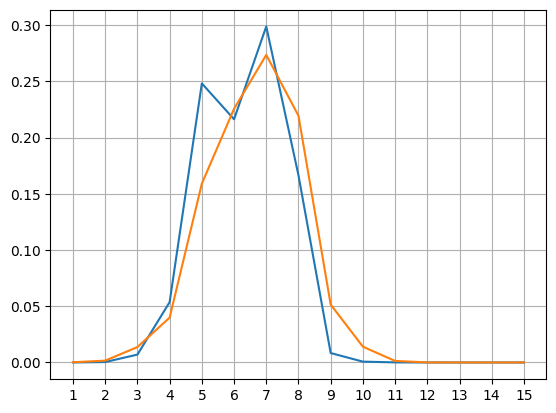

In [131]:
probs = run_model(best)
plt.plot(probs.detach().numpy())
plt.plot(init_probs)
plt.grid()
plt.xticks(ticks=range(d), labels=range(1, d+1))
plt.show()